# Define a location and analyse the time series of HOSTRADA/CERRA climate variables

In [1]:
import os

# Photon is the primary address service; Nominatim is used only as fallback.
# The order and endpoints remain configurable without changing the notebook.
os.environ.setdefault("HOSTRADA_GEOCODER_ORDER", "photon,nominatim")
import importlib
import html as html_lib
from datetime import date

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import requests
import ipywidgets as widgets
from IPython.display import display

from hostrada4py import hostradaPoint as hp
from hostrada4py import hostradaPointUI as hpui

os.environ["HOSTRADA_NETCDF_SUBSET_MODE"] = "full"
#os.environ["HOSTRADA_NETCDF_SUBSET_MODE"] = "auto"

## Interactive selection of the HOSTRADA value

In [1]:
from hostrada4py import providerUI as provider_ui

provider_selector = provider_ui.create_provider_selector(
    globals(),
    initial="dwd",
    title="Select weather data provider",
    show=True,
)

def _sync_notebook_provider(change=None):
    supported = {value for _, value in provider_ui.variable_options(provider_dropdown.value)}

    current_variable = globals().get("HOSTRADA_VAR")
    if current_variable is not None and current_variable not in supported:
        globals()["HOSTRADA_VAR"] = "tas" if "tas" in supported else next(iter(supported))

    selector = globals().get("variable_selector")
    if selector is not None and hasattr(selector, "options"):
        all_options = globals().get("_hostrada_all_variable_options")
        if all_options is None:
            all_options = list(selector.options)
            globals()["_hostrada_all_variable_options"] = all_options
        filtered = [
            option for option in all_options
            if (option[1] if isinstance(option, tuple) else option) in supported
        ]
        old_values = tuple(value for value in selector.value if value in supported)
        selector.value = ()
        selector.options = filtered
        available = [option[1] if isinstance(option, tuple) else option for option in filtered]
        selector.value = old_values or (("tas",) if "tas" in available else tuple(available[:1]))

    point_ui_instance = globals().get("point_ui")
    if point_ui_instance is not None and hasattr(point_ui_instance, "refresh_provider_scope"):
        point_ui_instance.refresh_provider_scope()

provider_dropdown.observe(_sync_notebook_provider, names="value")
_sync_notebook_provider()

In [3]:
# Climate variables available in the original notebook.
CLIMATE_VARIABLES = {
    "Outside air temperature (tas)": "tas",
    "Wind speed (sfcWind)": "sfcWind",
    "Wind direction (sfcWind_direction)": "sfcWind_direction",
    "Urban Heat Island Intensity (uhi)": "uhi",
    "Global radiation (rsds)": "rsds",
    "Cloud cover (clt)": "clt",
    "Relative humidity (hurs)": "hurs",
    "Water vapor mixing ratio (mixr)": "mixr",
    "Dew point temperature (tdew)": "tdew",
}

HOSTRADA_VAR = "tas"

climate_dropdown = widgets.Dropdown(
    options=[(label, value) for label, value in CLIMATE_VARIABLES.items()],
    value=HOSTRADA_VAR,
    description="Climate variable:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="560px"),
)
climate_status = widgets.HTML()

def _set_climate_variable(change=None):
    global HOSTRADA_VAR
    HOSTRADA_VAR = climate_dropdown.value
    selected_label = next(label for label, value in CLIMATE_VARIABLES.items() if value == HOSTRADA_VAR)
    climate_status.value = (
        f"<b>Selected:</b> {html_lib.escape(selected_label)} &nbsp; "
        f"(<code>HOSTRADA_VAR = '{HOSTRADA_VAR}'</code>)"
    )

climate_dropdown.observe(_set_climate_variable, names="value")
_set_climate_variable()
display(widgets.VBox([climate_dropdown, climate_status]))

## Interactive definition of the location and time period, and download of the HOSTRADA/CERRA values

In [4]:
point_ui = hpui.create_hostrada_point_ui(
    namespace=globals(),
    extractor=hp.extract_values_for_point,
    initial_lat=52.51712,
    initial_lon=13.32259,
    initial_address="Einsteinufer 43–53, 10587 Berlin",
    initial_start="2025-01-01T00:00",
    initial_end="2025-12-31T23:00",
    initial_output_directory=".",
    initial_output_filename=None,
)

# The address search follows the active provider dynamically.
# Photon is used first; Nominatim is a rate-limited fallback.
# DWD is restricted to Germany; CERRA searches across Europe.
point_ui.refresh_provider_scope()
display(point_ui.widget)

## Yearly time series of the HOSTRADA/CERRA variable

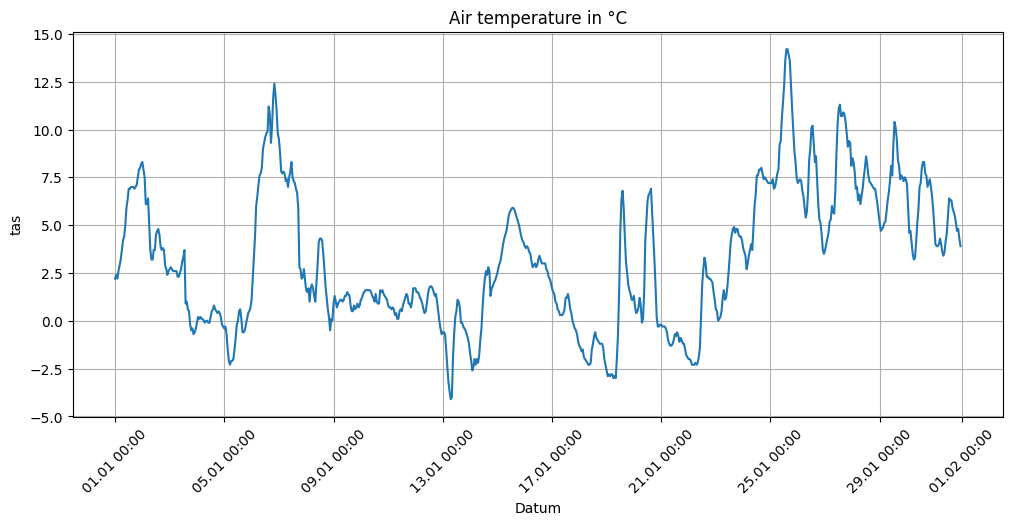

In [5]:
df = pd.read_csv(fn)
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time")

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(df["time"], df[HOSTRADA_VAR])
ax.set_xlabel("Datum")
ax.set_ylabel(HOSTRADA_VAR)

if HOSTRADA_VAR == "tas":
    title = "Air temperature in °C"
elif HOSTRADA_VAR == "uhi":
    title = "Urban Heat Island Intensity in °C"
elif HOSTRADA_VAR == "sfcWind":
    title = "Wind speed in m/s"
elif HOSTRADA_VAR == "sfcWind_direction":
    title = "Wind direction in degree"
elif HOSTRADA_VAR == "rsds":
    title = "Global radiation in W/m2"
elif HOSTRADA_VAR == "clt":
    title = "Cloud cover in eighth"
elif HOSTRADA_VAR == "hurs":
    title = "Relative humidity in percent"
elif HOSTRADA_VAR == "tdew":
    title = "Dew point temperature in °C"
elif HOSTRADA_VAR == "mixr":
    title = "Water vapor mixing ratio in g H20/kg dry air"
else:
    title = "unknown"
ax.set_title(title)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m %H:%M"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Monthly mean values of the HOSTRADA variable

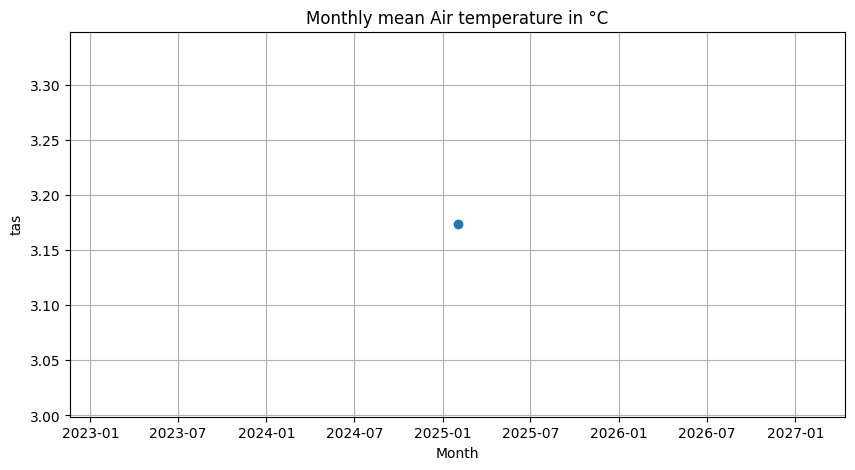

In [6]:
df = pd.read_csv(fn)
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time")
monthly_mean = df.resample("ME", on="time")[HOSTRADA_VAR].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_mean.index, monthly_mean.values, marker="o")
plt.xlabel("Month")
plt.ylabel(HOSTRADA_VAR)
if HOSTRADA_VAR == "tas":
    title = "Air temperature in °C"
elif HOSTRADA_VAR == "uhi":
    title = "Urban Heat Island Intensity in °C"
elif HOSTRADA_VAR == "sfcWind":
    title = "Wind speed in m/s"
elif HOSTRADA_VAR == "sfcWind_direction":
    title = "Wind direction in degree"
elif HOSTRADA_VAR == "rsds":
    title = "Global radiation in W/m2"
elif HOSTRADA_VAR == "clt":
    title = "Cloud cover in eighth"
elif HOSTRADA_VAR == "hurs":
    title = "Relative humidity in percent"
elif HOSTRADA_VAR == "tdew":
    title = "Dew point temperature in °C"
elif HOSTRADA_VAR == "mixr":
    title = "Water vapor mixing ratio in g H20/kg dry air"
else:
    title = "unknown"
plt.title("Monthly mean " + title)
plt.grid(True)
plt.show()

## Heatmap of the HOSTRADA variable

In [ ]:
df["dayofyear"] = df["time"].dt.dayofyear
df["hour"] = df["time"].dt.hour
heatmap_year = df.pivot_table(values=HOSTRADA_VAR, index="hour", columns="dayofyear")
plt.figure(figsize=(16,5))
sns.heatmap(heatmap_year, cmap="coolwarm", cbar_kws={"label": HOSTRADA_VAR})
plt.xlabel("Tag des Jahres")
plt.ylabel("Stunde")
plt.title("Annual cycle of " + HOSTRADA_VAR)
plt.show()

## Clustered Heatmap of the HOSTRADA variable

In [ ]:
df = pd.read_csv(fn)
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time")
df["month"] = df["time"].dt.month
df["hour"] = df["time"].dt.hour
climatology = df.pivot_table(values=HOSTRADA_VAR, index="hour", columns="month", aggfunc="mean")
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
plt.figure(figsize=(10,6))
sns.heatmap(climatology, cmap="coolwarm", xticklabels=months, cbar_kws={"label": HOSTRADA_VAR})
plt.xlabel("Month")
plt.ylabel("Hour")
plt.title("Climatological " + HOSTRADA_VAR)
plt.show()